In [29]:
import itertools
from collections import Counter
import matplotlib.pyplot as plt
import random 
def dice_distribution(dice_list, plot=True):
    """
    dice_list: [6,6] → два шестигранника
               [4,8,12] → три кубика
    """

    # диапазоны значений для каждого кубика
    dice_ranges = [range(1, sides + 1) for sides in dice_list]

    # все возможные комбинации
    all_rolls = itertools.product(*dice_ranges)

    # распределение сумм
    sums = [sum(roll) for roll in all_rolls]
    distribution = Counter(sums)

    # ==========================
    #   Перенумерация dict с 1
    # ==========================
    real_x_vals = sorted(distribution.keys())
    y_vals = [distribution[x] for x in real_x_vals]

    fake_distribution = {i + 1: y_vals[i] for i in range(len(y_vals))}

    if plot:
        total = sum(y_vals)

        # --- Кумулятивный процент ---
        cumulative = []
        running_sum = 0
        for y in y_vals:
            running_sum += y
            cumulative.append(running_sum / total * 100)

        # --- X начиная с 1 ---
        fake_x_vals = list(range(1, len(real_x_vals) + 1))

        plt.figure(figsize=(14, 7))
        plt.bar(fake_x_vals, y_vals)

        plt.xlabel("Номер столбика (старт с 1)")
        plt.ylabel("Количество комбинаций")
        plt.title(f"Распределение сумм для кубиков {dice_list}")

        # Все тики на оси X
        plt.xticks(fake_x_vals)

        # Кума
        for x, cum in zip(fake_x_vals, cumulative):
            plt.text(x, y_vals[x - 1], f"{cum:.1f}%", ha="center", va="bottom")

        plt.tight_layout()
        plt.show()

        # Мода (по реальным суммам)
        mode = max(distribution, key=distribution.get)
        print("Мода:", mode)

    return fake_distribution


In [44]:
d = 3

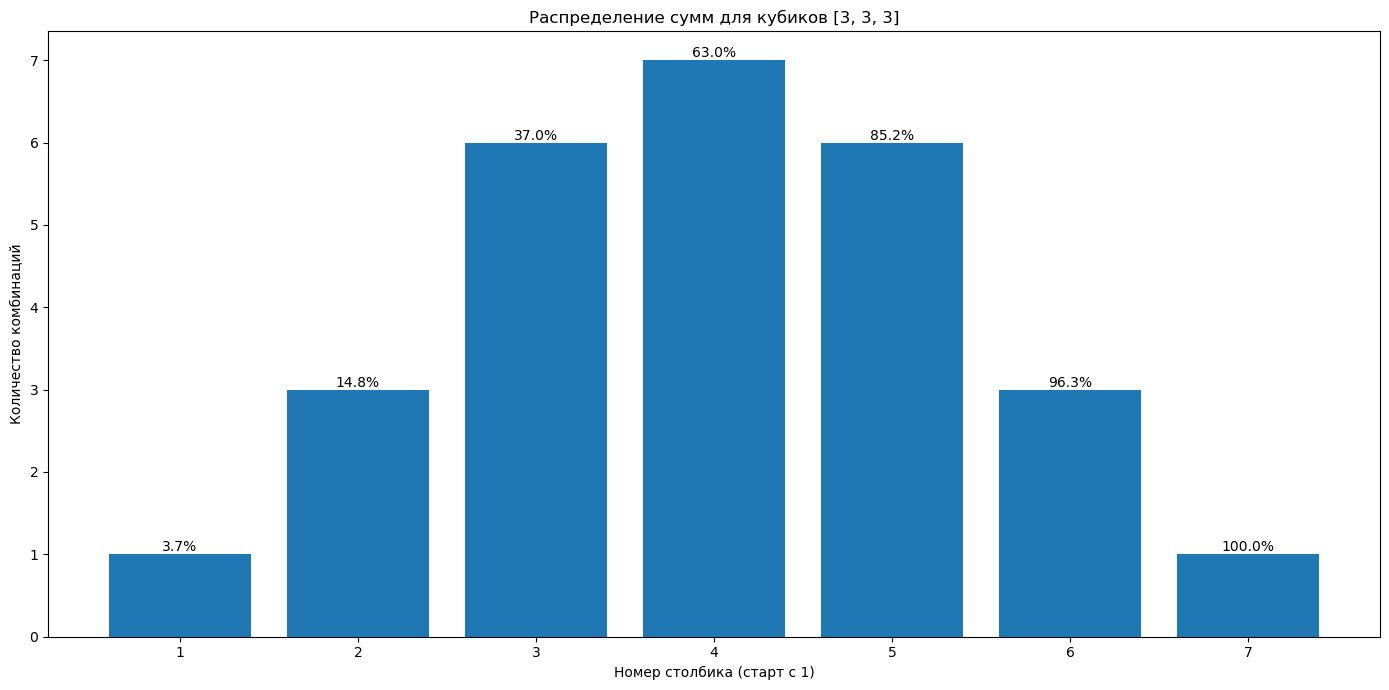

Мода: 6


{1: 1, 2: 3, 3: 6, 4: 7, 5: 6, 6: 3, 7: 1}

In [45]:
dice_distribution([d,d,d])

In [28]:

##### import random
from collections import Counter

results = []

r1 = 60
r2 = 60

# основной цикл
for _ in range(100000):

    # --- t1: сумма 2 кубиков d24 ---
    t1 = random.randint(1, r1)

    # --- t2: сумма 2 кубиков d60 ---
    t2 = random.randint(1, r2)

    # --- отношение t1/t2 округлённое ---
    ratio = t1 / t2

    results.append(ratio)

# --- маппинг в категории ---
def map_category(r):
    if r <= 0.3:
        return "засада"
    elif r < 0.8:
        return "поражение"
    elif r <= 1.25:
        return "ничья"
    elif r < 3.33:
        return "победа"
    else:
        return "разгром"


mapped = [map_category(r) for r in results]

# --- частоты ---
distribution = Counter(mapped)

# --- расчет процентов ---
total = len(results)
percentages = {k: round(v / total * 100, 1) for k, v in distribution.items()}

# вывод красиво
for category in ["засада", "поражение", "ничья", "победа", "разгром"]:
    print(f"{category}: {percentages.get(category, 0)}%")

засада: 14.4%
поражение: 25.1%
ничья: 20.6%
победа: 25.3%
разгром: 14.6%


In [27]:
z , por, n,pob, r

(14498, 25401, 20635, 25095, 14371)

In [12]:
z , por, n,pob, r
(1017, 2013, 1779, 2554, 1408)

(1017, 2013, 1779, 2554, 1408)